In [1]:
# TODO copy as "Ecell Fusion 2023-01-19" when more complete
# TODO remove dataset specific text when making finalized template

In [2]:
# Full notebook time profiling
from datetime import datetime
start_dt = datetime.now()

In [3]:
# Importing needed code

from pathlib import Path
from typing import Callable, Literal
from datetime import datetime, time, date, timedelta
from dataclasses import dataclass

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statistics as stat

from data_processing.processing.figure_of_merit import ( 
    FOM, 
    gaussian, 
    bimodal
)

from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter

Matplotlib created a temporary config/cache directory at /tmp/pbs.4627739.pbsha.ib.sockeye/matplotlib-h1orx2w0 because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


# Inputs

In [4]:
# Data location

experiment_name = 'E-cell_Fusion_1_Jan19-2023'

In [5]:
# Time period boundaries

rga_start_time = time.fromisoformat('12:00:00')
caen_start_time = time.fromisoformat('11:54:00')

on_end_offsets = ['01:26:00', '04:27:00']
off_end_offsets = ['02:58:00', '05:57:00']
duration = '00:45:00'

# Load Data

In [6]:
# Defining variables for important ARC folders

alloc_code = 'st-cberling-1'
project_folder = Path('/arc/project') / alloc_code
scratch_folder = Path('scratch') / alloc_code
input_data_folder = project_folder / 'input_data'

In [7]:
# Location of PSD data folder
PARQ_ROOT = input_data_folder / experiment_name / 'processed_data/unfiltered/psd'

In [8]:
%%time
# Load PSD data to "psd_report" DataFrame
psd_report = pd.read_parquet(PARQ_ROOT, columns=["CALIB_ENERGY","ENERGYSHORT", "ENERGY", "TIMETAG"])
psd_report = psd_report.astype({"CALIB_ENERGY": float, "ENERGYSHORT": int, "ENERGY": int, "TIMETAG": np.int64})

# Calculate PSD value as new column "tail / total"
psd_report["tail / total"] = (psd_report["ENERGY"] - psd_report["ENERGYSHORT"]) / psd_report["ENERGY"]
psd_report['TIMETAG_HOURS'] = psd_report['TIMETAG'] * 1e-12/3600
psd_report = psd_report.dropna()
psd_report = psd_report[psd_report["tail / total"].between(0,0.5)]
print(f"Dataset size: {psd_report.shape[0]:,} rows")
psd_report.head()

Dataset size: 2,627,499 rows
CPU times: user 2.34 s, sys: 467 ms, total: 2.81 s
Wall time: 2.98 s


,CALIB_ENERGY,ENERGYSHORT,ENERGY,TIMETAG,tail / total,TIMETAG_HOURS
0,0.763886,923,1088,9065858213,0.151654,0.000003
1,0.255336,319,361,12179764722,0.116343,0.000003
2,0.068829,77,94,23233068983,0.180851,0.000006
3,0.223193,257,315,27488491909,0.184127,0.000008
4,0.222495,268,314,56264741099,0.146497,0.000016


In [9]:
# Display dataset stats
max_timetag = psd_report["TIMETAG"].max()
total_time = max_timetag * 1e-12 # s
print(f"Total events = {psd_report.shape[0]}")
print(f"Total time = {total_time:.3f}s")

Total events = 2627499
Total time = 22141.697s


# Classify Neutrons

## Create 2D Histogram

In [10]:
# Create 2D histogram of PSD vs Energy data
# Generates 2D grid of "bins

resolution = int(1024/2)

x, y = psd_report["CALIB_ENERGY"], psd_report["tail / total"]
Z, xe, ye = np.histogram2d(x, y, resolution)

In [11]:
# Find energy slice width
energy_slice_width = xe[2] - xe[1]
f"Energy Slice Width = {energy_slice_width:.4f} MeVee"

'Energy Slice Width = 0.0056 MeVee'

## Analyse Event Distribution Across Energies

In [12]:
# TODO delete this when we get window using Californium source
# but keep in a FOM analysis notebook for when we need to recalibrate window

In [13]:
# FOM function definition

BimodalParams = tuple[float, float, float, float, float, float]
GaussianParams = tuple[float, float, float]
BimodalBounds = tuple[BimodalParams, BimodalParams]

def split_params(
    params: BimodalParams
) -> tuple[GaussianParams, GaussianParams]:
    """Separates bimodal function parameters into 2 sets, one per component gaussian
    
    Parameters
    ----------
    params: BimodalParams
        parameters of a bimodal function
        
    Returns
    -------
    lower_gaussian_params: GaussianParams
        Parameters of the lower gaussian (i.e. lower mu value)
    upper_gaussian_params: GaussianParams
        Parameters of the upper gaussian (i.e. higher mu value)
    """
    params = abs(params)
    return params[0:3], params[3:]

def get_bimodal_fit(
    bins: np.ndarray, 
    histogram_slice: np.ndarray, 
    bounds: BimodalBounds
) -> tuple[GaussianParams, GaussianParams, np.ndarray]:
    """Fits a histogram slice to a bimodal distribution
    
    Parameters
    ----------
    bins: ndarray
        Lower bounds of each PSD bin in the histogram
    histogram_slice: ndarray
        Slice of the 2D PSD/Energy histogram taken for a specific energy (i.e. PSD vs Counts)
    bounds: BimodalBounds
        Lower and upper bounds of fit parameters for this slice
        
    Returns
    -------
    gamma_params: GaussianParams
        Parameters of the gaussian fit for gamma rays
    neutron_params: GaussianParams
        Parameters of the gaussian fit for neutrons
    cov: ndarray
        Estimated covariance of all bimodial parameters
    """
    params, cov = curve_fit(
        bimodal,
        bins,
        histogram_slice,
        bounds=bounds,
    )
    
    gamma_params, neutron_params = split_params(params)
    
    return gamma_params, neutron_params, cov


def scan_histogram_slices(
    bins: np.ndarray, 
    histogram: np.ndarray, 
    default_bounds: BimodalBounds,
    bounds: list[tuple[tuple[int, int], BimodalBounds]] | None = None, 
    start_idx: int = 0, 
    end_idx: int | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Determines bimodal fit and FOM for every energy slice in 2D PSD/Energy histogram
    
    Parameters
    ----------
    bins: ndarray
        Lower bounds of each PSD bin in the histogram
    histogram: ndarray
        2D PSD/Energy histogram
    default_bounds: BimodalBounds
        Default lower and upper bounds of fit parameters
    bounds: list[tuple[tuple[int, int], BimodalBounds]] | None, default None
        Allows custom bounds for slice ranges. 
        Each list entry must have a tuple of start and stop indexes, and corresponding fit bounds.
        Bounds are used when the slice index falls within the start/stop range (start inclusive, stop exclusive).
        If index ranges overlap, the last matching range is used.
        If bounds is None, only default_bounds are used.
    start_idx: int, default 0
        Starting index (inclusive) of slice range to fit to bimodal
    end_idx: int | None, default None
        Ending index (exclusive) of slice range to fit to bimodal
        
    Returns
    -------
    fit_dataframe: DataFrame
        DataFrame of fit parameters including FOM (as columns) for each slice (as rows)
    error_dataframe: DataFrame
        DataFrame of (1 standard deviation) errors in fit parameters (as columns) for each slice (as rows)
    """
    end_idx = len(histogram) if end_idx is None else min(len(histogram), end_idx)
        
    slice_params = []
    slice_err = []
    
    for i in range(start_idx, end_idx):
        fit_bounds = default_bounds
        
        if bounds is not None :
            for i_range, bound in bounds:
                if i in range(*i_range):
                    fit_bounds = bound
        
        gamma_params, neutron_params, cov = get_bimodal_fit(bins, histogram[:,i], fit_bounds)
        
        fom = FOM(*gamma_params[:-1], *neutron_params[:-1])
        
        perr = np.sqrt(np.diag(cov))
    
        slice_params.append((i, *gamma_params, *neutron_params, fom))
        slice_err.append((i, *perr))
    
    columns = ['i', 'mu1', 'sigma1', 'a1', 'mu2', 'sigma2', 'a2']
    df = pd.DataFrame(slice_params, columns=columns + ['fom'])
    err_df = pd.DataFrame(slice_err, columns=columns)
    
    return df, err_df

In [14]:
%%time
# Scan 2D histogram's energy slices and get bimodal fit

psd_bin_lbs = ye[:-1]

# Default
default_bounds = (
    (0.1, 0.01, 1, 
     0.25, 0.01, 0),
    (0.2, 0.1, Z.max(),
     0.38, 0.04, 2000)
)

bounds_a = (
    (0.1, 0.01, 1, 
     0.35, 0.01, 0),
    (0.2, 0.1, Z.max(),
     0.36, 0.04, 2000)
)

bounds_b = (
    (0.1, 0.01, 1, 
     0.34, 0.01, 0),
    (0.2, 0.1, Z.max(),
     0.36, 0.03, 2000)
)


# Ranged Example
bounds = [
    ((0,60), bounds_a),
]

start_scan_idx = 0
end_scan_idx = 420

end_scan_idx = min(end_scan_idx, len(Z))

# df_fom = find_threshold_fom_slice(psd_bin_lbs, Z.T, bounds, 0, end_scan_idx)

df, df_err = scan_histogram_slices(
    psd_bin_lbs, 
    Z.T,
    bounds=bounds,
    default_bounds=default_bounds, 
    start_idx = start_scan_idx, 
    end_idx = end_scan_idx
)


df.head()

CPU times: user 7.88 s, sys: 79.9 ms, total: 7.96 s
Wall time: 7.99 s


,i,mu1,sigma1,a1,mu2,sigma2,a2,fom
0,0,0.142626,0.01,1.0,0.350000,0.031601,1.161229e-01,2.116853
1,1,0.149889,0.01,1.0,0.354779,0.010000,4.546592e-05,4.350445
2,2,0.149889,0.01,1.0,0.354779,0.010000,4.546592e-05,4.350445
3,3,0.149880,0.01,1.0,0.354779,0.010000,4.546591e-05,4.350636
4,4,0.132315,0.01,1.0,0.354779,0.010000,4.357633e-11,4.723593


In [15]:
# TODO get L0 from Californium source analysis
# for now, using value from "UBC Background 20221214-19 Update"
# TODO change this variable name to something more descriptive
L0 = 0.1966

## Classify Neutrons

In [16]:
# Window fitting function definition

window_adj_offset = 0
fontsize=24

def classify(
    psd_report: pd.DataFrame, 
    lb_fit_fn: Callable[[np.ndarray], np.ndarray], 
    ub_fit_fn: Callable[[np.ndarray], np.ndarray], 
    label: str, 
    le_cutoff: float = L0
) -> pd.DataFrame:
    """Classify signals as neutron or non-neutron for a given count window
    Classification creates a new column of boolean values, where True indicates a neutron classified signal.
    
    Parameters
    ----------
    psd_report: DataFrame
        DataFrame containing signal PSD data. 
        It must have the "tail / total" (for PSD value) and "CALIB_ENERGY" (for calibrated energy) columns.
    lb_fit_fn: Callable[[ndarray], ndarray]
        A function describing the window's lower bounds
    ub_fit_fn: Callable[[ndarray], ndarray]
        A function describing the window's upper bounds
    label: str
        Column label to use for signal classification results
    le_cutoff: float, default L0 (previously determined lower energy cutoff)
        Lower energy cutoff (AKA the left boundary of the neutron window)
        
    Returns
    -------
    psd_report: DataFrame
        Original DataFrame with new column for neutron classification
    """
    psd_report[label] = psd_report["tail / total"].between(
        lb_fit_fn(psd_report["CALIB_ENERGY"].astype(float)) + 
        window_adj_offset, ub_fit_fn(psd_report["CALIB_ENERGY"].astype(float))
    ) & (psd_report["CALIB_ENERGY"] >= le_cutoff)
    
    return psd_report

def plot_classification(
    neutrons: pd.DataFrame, 
    gammas: pd.DataFrame, 
    lb_fit: Callable[[float], float],
    ub_fit: Callable[[float], float],
    max_energy: float,
    FOM_cutoff: float,
    n_neutrons: int,
    label_n: str = "Neutrons",
    label_g: str = "Non-Neutrons",
) -> tuple[plt.Figure, plt.Axes]:
    """Plot detected events, showing neutron classification window
    The classification window's upper and lower PSD bound functions, as well as the energy cutoff (left side) bound,
    are shown as dotted lines. Points are color labelled to show neutron vs. non-neutron events.
    
    Parameters
    ----------
    neutrons: pd.DataFrame
        DataFrame of neutron classified events to display
    gammas: pd.DataFrame
        DataFrame of non-neutron classified events to display (assumed to be gamma rays)
    lb_fit, ub_fit: Callabl[[float], float]
        Lower and upper PSD bound functions
    max_energy: float
        Maximum energy used in this plot (which determines x-axis range)
    FOM_cutoff: float
        Energy cutoff, i.e. lowest energy where FOM > 1.27
    n_neutrons: int
        Actual total number of neutrons (to be displayed in title)
        This parameter is used rather than obtained from the neutrons DataFrame
        to allow data samples to be plotted for faster plotting.
    label_n: str
        Series label for neutron classified events
    label_g: str
        Series label for non-neutron classified events (AKA gamma rays)
    
    Returns
    -------
    fig: plt.Figure
        Plotting container for neutron classification plot
    ax: plt.Axes
        Plot axes for neutron classification plot
    
    """
    fig, ax = plt.subplots(figsize=(10,10))
    ax.scatter(gammas["CALIB_ENERGY"], gammas["tail / total"], s=2, label=label_g)
    ax.scatter(neutrons["CALIB_ENERGY"], neutrons["tail / total"], s=2, label=label_n)

    energy_space = np.linspace(xe[0], max_energy + 0.5, 200)

    ax.plot(energy_space, lb_fit(energy_space), 'r--')
    ax.plot(energy_space, ub_fit(energy_space), 'r--')
    
    ax.vlines(all_slice_xs[0], lb_fit(all_slice_xs[0]), ub_fit(all_slice_xs[0]), 'r', ls='--')

    ax.vlines(FOM_cutoff, lb_fit(FOM_cutoff), ub_fit(FOM_cutoff), 'r', ls="--")

    ax.set_title(f"Counts = {n_neutrons}", fontsize=fontsize)
    ax.set_ylim(0, 0.55)
    ax.set_xlim(0, max_energy + .05)
    
    ax.tick_params(axis='both', which='major', labelsize=22)
    ax.tick_params(axis='both', which='minor', labelsize=22)
    
    ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)
    ax.set_ylabel("PSD", fontsize=fontsize)
    ax.legend(fontsize=fontsize)
    return fig, ax

In [17]:
# Define variable for all slice indexes to use
# (can be overridden if you only want to plot a subset of x axis)

all_slice_xs = xe[:end_scan_idx]

### Apply NASA Neutron Classification Window


This classification window is based on the technique outlined in _Fast Neutron Spectroscopy With Organic Scintillation Detectors in a High-Radiation Environment_, Baramsai _et al_.

We define the lower PSD bound as N standard deviations above the gamma mean. We find these points for each slice, then use smoothing and interpolation to generate a lower bound function.

The upper bound for the window is generated by adding a fixed offset to the lower bound value (found to be 0.2 based on observation of the paper's graphs).

As in all windows, the FOM cutoff is used as the left-most bound.

In [18]:
# Define lower and upper bounds (neutron_lb_fit, neutron_ub_fit)

window_offset = 0.2
sigma = 5

neutron_lb = savgol_filter(df["mu1"] + sigma * df["sigma1"], window_length=21, polyorder=3)  # reduce noise
neutron_lb_fit = interp1d(
    all_slice_xs, 
    neutron_lb, 
    fill_value=(neutron_lb[0], neutron_lb[-1]), 
    bounds_error=False)  # now it's a function!

def neutron_ub_fit(x):
    # upper bound is just a fixed PSD offset from lower bound
    # as observed in NASA paper graphs
    return neutron_lb_fit(x) + window_offset

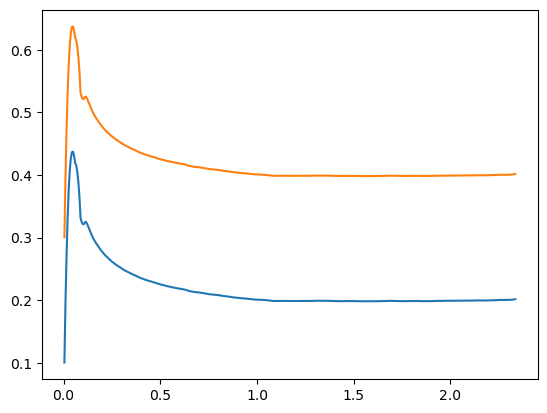

In [19]:
# Plot upper and lower bounds (diagnostic)

plt.plot(all_slice_xs, neutron_lb_fit(all_slice_xs))
plt.plot(all_slice_xs, neutron_ub_fit(all_slice_xs))

In [20]:
%%time
# Classify neutrons under NASA window
psd_report = classify(psd_report, neutron_lb_fit, neutron_ub_fit, "NASA",le_cutoff=L0)

CPU times: user 381 ms, sys: 2.01 ms, total: 383 ms
Wall time: 388 ms


In [21]:
%%time
# Generate random sample of "psd_report" for graphing
# Graphing 300M points is way too slow, so best to graph a reasonable fraction of all points

sample_frac = 0.1  # fraction of points to put in sample (0-1)
random_state = 1323  # random number generator seed; change to try different samples

if sample_frac >= 1:
    graph_sample = psd_report
else:
    graph_sample = psd_report.sample(frac=sample_frac,random_state=random_state)

CPU times: user 86.9 ms, sys: 1.94 ms, total: 88.9 ms
Wall time: 92.6 ms


In [22]:
plot_start = datetime.now()

(<Figure size 1000x1000 with 1 Axes>,
 <AxesSubplot: title={'center': 'Counts = 3205'}, xlabel='Energy (MeVee)', ylabel='PSD'>)

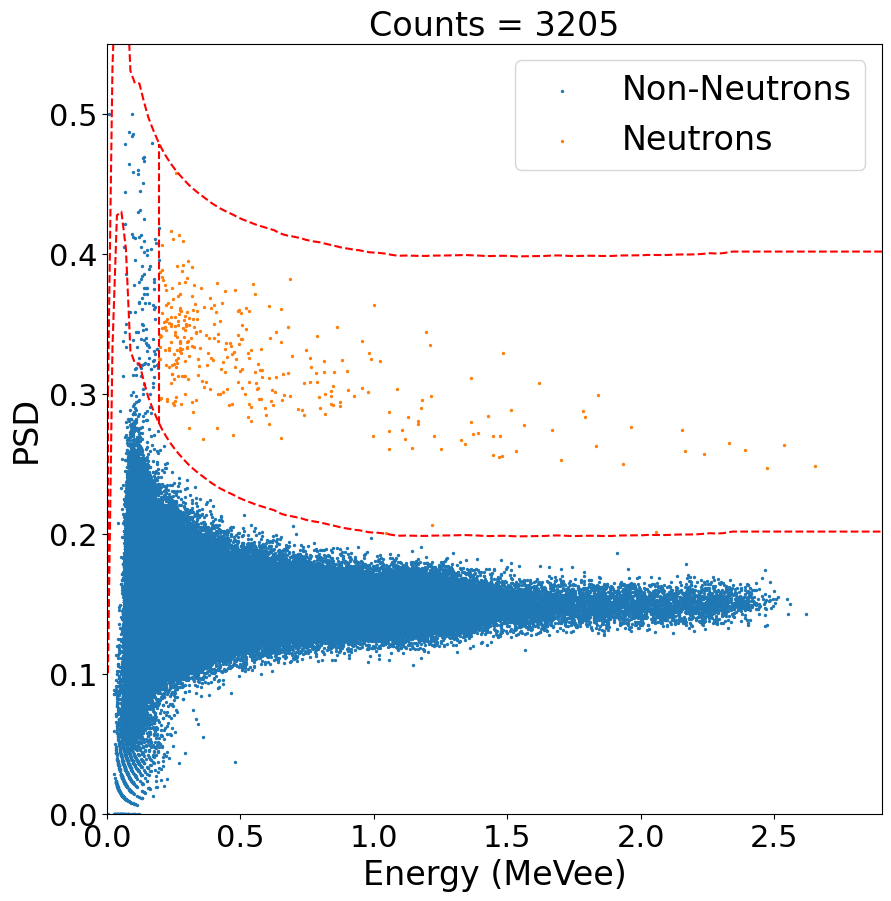

In [23]:
# Plotting NASA classification
plot_classification(
    graph_sample[graph_sample["NASA"]], 
    graph_sample[~graph_sample["NASA"]], 
    neutron_lb_fit, 
    neutron_ub_fit, 
    psd_report["CALIB_ENERGY"].max(), 
    L0,
    psd_report[psd_report["NASA"]].shape[0]
)
# plt.plot(all_slice_xs, df["mu2"])
# plt.plot(all_slice_xs, df["mu1"] + 4 * df["sigma1"])
# plt.xlim(0.2,0.4)
# plt.ylim(0.3, 0.5)

In [24]:
plot_end = datetime.now()
plot_duration = plot_end - plot_start
print(f"Plot execution time: {plot_duration.total_seconds():.3f} s")

Plot execution time: 2.072 s


## Device Period Classification

In [25]:
def timetag_generator(start_time: time) -> Callable[[time], int]:
    """Get a function that generates timetags from the start time.
    Timetags are measured in picoseconds from the starting time
    
    Parameters
    ----------
    start_time: time
        Starting time used by the produced timetag generator function.
        
    Returns
    -------
    fn: Callable[[time], int]
        A function that produces timetag for a given end time.
    """

    def get_timetag(end_time: time) -> int:
        """Generates timetag for a given end time.
        
        Parameters
        ----------
        end_time: time
            Time to be converted into a timetag
            
        Returns
        -------
        timestamp: int
            Timetag for the given time
        """
        end_datetime = datetime.combine(date.today(), end_time)
        start_datetime = datetime.combine(date.today(), start_time)
        total_seconds = end_datetime - start_datetime
        return int(total_seconds.total_seconds() * 1e12)
    
    return get_timetag


def offset_from_timestring(timestring: str) -> timedelta:
    """Converts an ISO format time string into a time duration
    
    Parameters
    ----------
    timestring: str
        ISO format time string to be converted
        
    Returns
    -------
    delta: timedelta
        Corresponding duration
    """
    hour_str, min_str, sec_str = timestring.split(":")
    return timedelta(
        hours=int(hour_str),
        minutes=int(min_str),
        seconds=int(sec_str)
    )

def offsets_from_timestrings(timestrings: list[str]) -> list[timedelta]:
    """Converts a list of ISO format time strings into a list of time durations
    
    Parameters
    ----------
    timestrings: list[str]
        List of timestrings to be converted
    
    Returns
    -------
    deltas: list[timedelta]
        List of corresponding durations
    """
    return [offset_from_timestring(timestring) for timestring in timestrings]

def time_difference(a: time, b: time) -> timedelta:
    """Find the difference between two times
    
    Parameters
    ----------
    a, b: time
        The given times
    
    Returns
    -------
    difference: timedelta
        The difference between the given times
    """
    dt_a = datetime.combine(date.today(), a)
    dt_b = datetime.combine(date.today(), b)
    return dt_a - dt_b

def get_period_bounds_timetags(
    detector_start: time,
    gas_analyzer_start: time,
    start_offsets: list[timedelta] | None = None,
    end_offsets: list[timedelta] | None = None,
    period_duration: timedelta | None = None
) -> list[tuple[int, int]]:
    """Find the timetags that bound a series of time periods based 
    on start and stop time offsets. 
    Timetags are used by the neutron detector, and are expressed in 
    picoseconds after the detector was started.
    Offsets are taken from the gas analyzer, and are therefore counted 
    from the start of that device.
    At least 2 of start_offsets, end_offsets and period_duration are used.
    If all 3 are present, start_offsets and end_offsets are used.
    
    Parameters
    ----------
    detector_start: time
        The start time of neutron detection on the CAEN software
    gas_analyzer_start: time
        The start time of the RGA gas analyser
    start_offsets: Optional[list[timedelta]], default None
        A list of time offsets representing the start of each period in
        the series
    end_offsets: Optional[list[timedelta]], default None
        A list of time offsets representing the end of each period in the 
        series
    period_duration: Optional[timedelta], default None
        The length of each period
    
    Returns
    -------
    bounds_timetags: list[tuple[int, int]]
        The start and end timetags for each period in the series
    """
    if period_duration is not None:
        if start_offsets is None and end_offsets is None:
            raise ValueError(
                "At least 2 of start_times, end_times and period_duration must be given."
            )
    else:
        if start_offsets is None or end_offsets is None:
            raise ValueError(
                "At least 2 of start_times, end_times and period_duration must be given."
            )
    
    if start_offsets is not None and end_offsets is not None and len(start_offsets) != len(end_offsets):
        raise ValueError(
            "Start and end offsets must have the same length"
        )
    
    gas_analyzer_start: datetime = datetime.combine(date.today(), 
                                                    gas_analyzer_start)
    
    if start_offsets is not None:
        start_times: list[datetime] = [gas_analyzer_start + delta
                                       for delta in start_offsets]
    if end_offsets is not None:
        end_times: list[datetime] = [gas_analyzer_start + delta
                                     for delta in end_offsets]
        
    if start_offsets is None:
        start_times = [end_time - period_duration 
                       for end_time in end_times]
    if end_offsets is None:
        end_times = [start_time + period_duration 
                     for start_time in start_times]
    
    start_times: list[time] = [dtime.time() for dtime in start_times]
    end_times: list[time] = [dtime.time() for dtime in end_times]
    
    get_timetag = timetag_generator(detector_start)
    
    start_timetags = [*map(get_timetag, start_times)]
    end_timetags = [*map(get_timetag, end_times)]
    timetags = list(zip(start_timetags, end_timetags))
    return timetags

def classify_period(
    dataframe: pd.DataFrame,
    column_name: str, 
    timetags: list[tuple[int, int]]
) -> pd.DataFrame:
    """Classifies events in a period of time, and in the overall period series.
    
    Classification is done by adding new columns to the given dataframe.
    All periods in the series are classified using the given name, and 
    individual periods are classified using the given name with an
    understore and the period index appended. (For example, if the 
    given column name was "PLASMA_ON", the periods would be classified 
    under "PLASMA_ON_0", "PLASMA_ON_1", and so on.)
    
    Parameters
    ----------
    dataframe: pd.DataFrame
        Dataframe with events to be classified
    column_name: str
        Base classification column name
    timetags: list[tuple[int, int]]
        List of bounds timetags for each period
    
    """
    # TODO change this to use category column and pd.cut()
    # Adds column to dataframe classifying events 
    # as happening in any of a series of time intervals
    # Get start/end timestamps from get_period_bounds_timestamps
    
    all_period_series = {i: dataframe['TIMETAG'].between(start, end)
                        for i, (start, end) in enumerate(timetags)}
    overall_series = pd.DataFrame(all_period_series).any(axis='columns')
    
    dataframe[column_name] = overall_series
    for i, period_series in all_period_series.items():
        dataframe[f"{column_name}_{i}"] = period_series
    return dataframe

In [26]:
%%time

on_end_offsets: list[timedelta] = offsets_from_timestrings(on_end_offsets)
off_end_offsets: list[timedelta] = offsets_from_timestrings(off_end_offsets)
duration: timedelta = offset_from_timestring(duration)
    
bounds_timetags = [
    get_period_bounds_timetags(
        caen_start_time, 
        rga_start_time, 
        end_offsets=offsets, 
        period_duration=duration
    ) for offsets in (on_end_offsets, off_end_offsets)
]
on_bounds_timetags, off_bounds_timetags = bounds_timetags

psd_report = classify_period(
    psd_report, 
    'ECELL_ON',
    timetags=on_bounds_timetags
)
psd_report = classify_period(
    psd_report,
    'ECELL_OFF',
    timetags=off_bounds_timetags
)

CPU times: user 44.3 ms, sys: 1.03 ms, total: 45.3 ms
Wall time: 45.5 ms


Text(0.5, 0, 'Time (hours)')

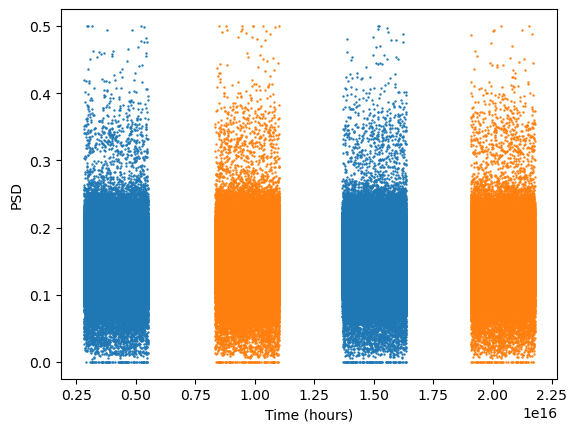

In [27]:
# Visualize time classification (optional, diagnostic)

# TODO simplify this into a timeline graph (how to do that?)
test = psd_report[psd_report["ECELL_ON"]]
test2 = psd_report[psd_report["ECELL_OFF"]]
plt.scatter(test["TIMETAG"], test["tail / total"], s=0.5)
plt.scatter(test2["TIMETAG"], test2["tail / total"], s=0.5)
plt.ylabel("PSD")
plt.xlabel("Time (hours)")

## Fusion Analysis

### Setting up Trial data structure

In [28]:
# Function definition
# Experiment dataclass definition

def get_sigma_for_count(count: int) -> float:
    """Calculates estimated error for a given event count
    
    Parameters
    ----------
    count: int
        Event count
        
    Returns
    -------
    sigma: float
        Estimated error for the given event count
    """
    return np.sqrt(abs(count))

def get_sigma_for_count_delta(a:int, b:int) -> float:
    """Calculates estimated error for a difference between (or sum of) event counts
    
    Parameters
    ----------
    a, b: int
        Event counts
    
    Returns
    -------
    sigma: float
        Estimated error for the difference between (or sum of) the event counts
    """
    sigma_a = get_sigma_for_count(a)
    sigma_b = get_sigma_for_count(b)
    return np.sqrt(sigma_a**2 + sigma_b**2)

def counts_over_time_histogram(
    timetags: pd.Series, 
    dwell_time: int, 
    start_timetag: int,
    end_timetag: int
) -> tuple[np.ndarray, np.ndarray]:
    """Generates histogram of event counts per dwell time bin over a time period
    
    Parameters
    ----------
    timetags: pd.Series
        timetags (as picoseconds after neutron detector start) for all relevant events 
    dwell_time: int
        time period used for histogram bin width in seconds
    start_timetag: int
        starting timetag (as picoseconds after neutron detector start) for histogram period
    end_timetag: int
        ending timetag (as picoseconds after neutron detector start) for histogram period
    
        
    Returns
    -------
    counts: np.ndarray
        array of counts per bin
    bins: np.ndarray
        bin boundaries (as time in seconds)
    """
#     if total_time % dwell_time == 0:
#         total_time += 0.001
#     input_bins = np.arange(0, total_time, dwell_time)
    dwell_time = dwell_time * 1e12
    if (end_timetag - start_timetag) % dwell_time == 0:
        end_timetag += 1
    input_bins = np.arange(start_timetag, end_timetag, dwell_time)
    counts, bins = np.histogram(timetags, input_bins)
    return counts, bins

@dataclass
class Trial:
    """Class for storing trial data and calculating derived data.
    Each trial has a condition period, during which some experimental
    device was active (i.e. E-cell, plasma, etc.), and a background 
    period, during which the device was not active.
    To ensure correct results, the experimental state should be stable 
    before either period starts. For example, if some experimental parameter
    such as a chemical concentration takes time to increase when the device
    is active, the condition period should only start when that parameter
    reaches a steady value.
    To ensure correct event rate statistics, the condition and background 
    periods should have equal durations.
    
    Parameters
    ----------
    condition_dataframe: pd.DataFrame
        DataFrame containing only events in the condition period
    background_dataframe: pd.DataFrame
        DataFrame containing only events in the background period
    condition_time_bounds: tuple[int, int]
        The timetags that bound the condition period
    background_time_bounds: tuple[int, int]
        The timetags that bound the background period
    """
    condition_dataframe: pd.DataFrame
    background_dataframe: pd.DataFrame
    condition_time_bounds: tuple[int, int]
    background_time_bounds: tuple[int, int]
    
    EPSILON = 1e-6
    
    @property
    def condition_count(self) -> int:
        """The total event count in the condition period"""
        return self.condition_dataframe.shape[0]
    
    @property
    def background_count(self) -> int:
        """The total event count in the background period"""
        return self.background_dataframe.shape[0]
    
    @property
    def condition_time(self) -> float:
        """The total duration of the condition period"""
        start, end = self.condition_time_bounds
        return (end - start) * 1e-12
    
    @property
    def background_time(self) -> float:
        """The total duration of the background period"""
        start, end = self.background_time_bounds
        return (end - start) * 1e-12
    
    def count_delta(self):
        """The difference in total counts between condition and background periods"""
        return self.condition_count - self.background_count

    # Rate methods
    def condition_rate(self):
        """The overall average rate for the condition period"""
        return self.condition_count/self.condition_time
    
    def background_rate(self):
        """The overall average rate for the background period"""
        return self.background_count/self.background_time
    
    def rate_delta(self):
        """The difference in averages rates between condition and background periods"""
        return self.condition_rate() - self.background_rate()
    
    def rate_delta_is_valid(self):
        """Returns True if the condition and background periods have effectively equal durations.
        If this is true, we can consider the calculated rate difference to valid and useful.
        "Effectively equal" means the duration difference is below a small threshold.
        """
        delta_time = abs(self.condition_time - self.background_time)
        return delta_time < self.EPSILON
    
    # Error estimation methods
    def condition_sigma(self):
        """The estimated error in the condition periods' total event count"""
        return get_sigma_for_count(self.condition_count)
    
    def background_sigma(self):
        """The estimated error in the background periods' total event count"""
        return get_sigma_for_count(self.background_count)
    
    def delta_sigma(self):
        """The estimated error in the event count difference"""
        return get_sigma_for_count_delta(self.condition_sigma(), 
                                         self.background_sigma())
    
    def condition_rate_sigma(self):
        """The estimated error in the condition period's average rate"""
        return self.condition_sigma()/self.condition_time
    
    def background_rate_sigma(self):
        """The estimated error in the background period's average rate"""
        return self.background_sigma()/self.background_time
    
    def rate_delta_sigma(self):
        """The estimated error in the average rate difference"""
        return get_sigma_for_count_delta(
            self.condition_rate_sigma(), 
            self.background_rate_sigma())

    # Statistical significance methods
    def is_rate_significantly_larger(self, sigmas: float) -> bool:
        cond_error_bounds = (self.condition_rate() - sigmas*self.condition_rate_sigma(), 
                             self.condition_rate() + sigmas*self.condition_rate_sigma())
        bg_error_bounds = (self.background_rate() - sigmas*self.background_rate_sigma(),
                           self.background_rate() + sigmas*self.background_rate_sigma())
        
        is_larger = self.condition_rate() > self.background_rate()
        # is_overlapping method from https://stackoverflow.com/a/12888920/1239124
        is_overlapping = (max(cond_error_bounds[0], bg_error_bounds[0]) <= 
                          min(cond_error_bounds[1], bg_error_bounds[1]))
        
        return is_larger and not is_overlapping
    
    # Rate histogram methods
    def condition_rate_over_time(
        self, dwell_time: int
    ) -> tuple[np.ndarray, np.ndarray]:
        """Determines the condition period's event rate over time as 
        a histogram.
        
        The condition period is divided into time "bins", and event rates 
        are calculated for each bin.
        
        Parameters
        ----------
        dwell_time: int
            Time bin duration. If the dwell time is such that the final
            bin would be smaller than the dwell time, it is not used.
            Therefore, each time bin always lasts the full dwell time.
            For example, for a period lasting 15 minutes, a dwell time of 
            6 minute would produce only 2 bins of 6 minutes long, with the
            remaining 3 minutes ignored.
            
        Returns
        -------
        rates: np.ndarray
            The event rates for each time bin
        bins: np.ndarray
            The timetag boundaries for each time bin. Since the bins are
            contiguous, and adjacent bins share a boundary, the bins array
            is always one element longer than the rates array.
        """
        return self._rate_over_time(
            dwell_time,
            self.condition_dataframe,
            self.condition_time_bounds
        )
    
    def background_rate_over_time(
        self, dwell_time: int
    ) -> tuple[np.ndarray, np.ndarray]:
        """Determines the background period's event rate over time as 
        a histogram.
        
        The background period is divided into time "bins", and event rates 
        are calculated for each bin.
        
        Parameters
        ----------
        dwell_time: int
            Time bin duration. If the dwell time is such that the final
            bin would be smaller than the dwell time, it is not used.
            Therefore, each time bin always lasts the full dwell time.
            For example, for a period lasting 15 minutes, a dwell time of 
            6 minute would produce only 2 bins of 6 minutes long, with the
            remaining 3 minutes ignored.
            
        Returns
        -------
        rates: np.ndarray
            The event rates for each time bin
        bins: np.ndarray
            The timetag boundaries for each time bin. Since the bins are
            contiguous, and adjacent bins share a boundary, the bins array
            is always one element longer than the rates array.
        """
        return self._rate_over_time(
            dwell_time,
            self.background_dataframe,
            self.background_time_bounds
        )
    
    def condition_rate_histogram(
        self, dwell_time: int, rate_bin_count: int
    ) -> tuple[np.ndarray, np.ndarray]:
        """Determines the condition period's event rate distribution as 
        a histogram.
        
        The event rate histogram is calculated as in the 
        condition_rate_over_time() method. Then, rate bins are produced,
        and the number of rates falling in each bin are counted.
        
        Parameters
        ----------
        dwell_time: int
            Time bin duration for calculating event rates. 
            If the dwell time is such that the final bin would be smaller 
            than the dwell time, it is not used. Therefore, each time bin 
            always lasts the full dwell time. For example, for a period 
            lasting 15 minutes, a dwell time of 6 minute would produce 
            only 2 bins of 6 minutes long, with the remaining 3 minutes 
            ignored.
        rate_bin_count: int
            The number of rate bins to use
            
        Returns
        -------
        counts: np.ndarray
            The count for each event rate bin
        bins: np.ndarray
            The rate boundaries for each event rate bin. Since the bins 
            are contiguous, and adjacent bins share a boundary, the bins 
            array is always one element longer than the rates array.
        """
        rates, _ = self.condition_rate_over_time(dwell_time)
        return np.histogram(rates, rate_bin_count)
    
    def background_rate_histogram(
        self, dwell_time: int, rate_bin_count: int
    ) -> tuple[np.ndarray, np.ndarray]:
        """Determines the background period's event rate distribution as 
        a histogram.
        
        The event rate histogram is calculated as in the 
        condition_rate_over_time() method. Then, rate bins are produced,
        and the number of rates falling in each bin are counted.
        
        Parameters
        ----------
        dwell_time: int
            Time bin duration for calculating event rates. 
            If the dwell time is such that the final bin would be smaller 
            than the dwell time, it is not used. Therefore, each time bin 
            always lasts the full dwell time. For example, for a period 
            lasting 15 minutes, a dwell time of 6 minute would produce 
            only 2 bins of 6 minutes long, with the remaining 3 minutes 
            ignored.
        rate_bin_count: int
            The number of rate bins to use
            
        Returns
        -------
        counts: np.ndarray
            The count for each event rate bin
        bins: np.ndarray
            The rate boundaries for each event rate bin. Since the bins 
            are contiguous, and adjacent bins share a boundary, the bins 
            array is always one element longer than the rates array.
        """
        rates, _ = self.background_rate_over_time(dwell_time)
        return np.histogram(rates, rate_bin_count)
    
    # Stat reporting methods
    def report_count_statistics(self):
        """Prints count statistics for this trial.
        This includes condition and background counts, count difference,
        and estimated error for each.
        """
        print(f"Condition count: {self.condition_count}, Error: {self.condition_sigma():.4f}")
        print(f"Background count: {self.background_count}, Error: {self.background_sigma():.4f}")
        print(f"Count difference: {self.count_delta()}, Error: {self.delta_sigma():.4f}")
    
    def report_rate_statistics(self):
        """Prints rate statistics for this trial.
        This includes condition and background rates, rate difference 
        (with validity), and estimated error for each.
        """
        print(f"Condition rate: {self.condition_rate():.4f}, Error: {self.condition_rate_sigma():.4f}")
        print(f"Background rate: {self.background_rate():.4f}, Error: {self.background_rate_sigma():.4f}")
        print(f"Rate difference: {self.rate_delta():.4f}, Error: {self.rate_delta_sigma():.4f}")
        print(f"Rate difference is{'' if self.rate_delta_is_valid() else ' not'} valid (times = {self.condition_time:.4f}, {self.background_time:.4f})")
    
    def report_rate_significance(self, sigmas: float):
        significance = self.is_rate_significantly_larger(sigmas)
        print(f"Condition rate {self._is_or_is_not(significance)} significantly larger at {sigmas} sigmas")
    
    # Helpers
    def _rate_over_time(
        self, 
        dwell_time: int, 
        df: pd.DataFrame, 
        bounds: tuple[int, int]
    ) -> tuple[np.ndarray, np.ndarray]:
        counts, bins = counts_over_time_histogram(
            df['TIMETAG'],
            dwell_time,
            *bounds)
        rates = counts/dwell_time
        return rates, bins

    def _is_or_is_not(self, value: bool) -> str:
        return 'is' if value else 'is not'
        

def report_overall_count_statistics(trials: list[Trial]):
    """Reports overall count statistics for a list of trials."""
    total_cond_count = sum([trial.condition_count for trial in trials])
    total_bg_count = sum([trial.background_count for trial in trials])
    total_delta = total_cond_count - total_bg_count
    
    sigma_cond_count = get_sigma_for_count(total_cond_count)
    sigma_bg_count = get_sigma_for_count(total_bg_count)
    sigma_delta = get_sigma_for_count_delta(total_cond_count, total_bg_count)
    
    print(f"Condition count: {total_cond_count}, Error: {sigma_cond_count:.4f}")
    print(f"Background count: {total_bg_count}, Error: {sigma_bg_count:.4f}")
    print(f"Count difference: {total_delta:.4f}, Error: {sigma_delta:.4f}")

In [29]:
on_query = [f"NASA & ECELL_ON_{i}" for i in range(len(on_end_offsets))]
off_query = [f"NASA & ECELL_OFF_{i}" for i in range(len(off_end_offsets))]

on_df = [psd_report.query(query) for query in on_query]
off_df = [psd_report.query(query) for query in off_query]

trials_setup = list(zip(on_df, off_df, on_bounds_timetags, off_bounds_timetags))
trials = [Trial(*inputs) for inputs in trials_setup]

### Overall Statistics

In [30]:
report_overall_count_statistics(trials)

Condition count: 770, Error: 27.7489
Background count: 782, Error: 27.9643
Count difference: -12.0000, Error: 39.3954


### Trial Statistics

In [31]:
for i, trial in enumerate(trials):
    print(f"Trial {i+1}:")
    trial.report_count_statistics()
    print()
    trial.report_rate_statistics()
    trial.report_rate_significance(1)
    print("--------------------")
    print()

Trial 1:
Condition count: 389, Error: 19.7231
Background count: 381, Error: 19.5192
Count difference: 8, Error: 6.2644

Condition rate: 0.1441, Error: 0.0073
Background rate: 0.1411, Error: 0.0072
Rate difference: 0.0030, Error: 0.1206
Rate difference is valid (times = 2700.0000, 2700.0000)
Condition rate is not significantly larger at 1 sigmas
--------------------

Trial 2:
Condition count: 381, Error: 19.5192
Background count: 401, Error: 20.0250
Count difference: -20, Error: 6.2884

Condition rate: 0.1411, Error: 0.0072
Background rate: 0.1485, Error: 0.0074
Rate difference: -0.0074, Error: 0.1210
Rate difference is valid (times = 2700.0000, 2700.0000)
Condition rate is not significantly larger at 1 sigmas
--------------------



### Count Rate Plot

In [32]:
# Define functions used in count rate plotting
def combine_period_histograms(
    counts: list[np.ndarray], 
    bins: list[np.ndarray]
) -> tuple[np.ndarray, np.ndarray]:
    """Combines period histograms together for proper plotting.
    Since periods are not adjacent, we must properly define the value
    of the intervening time as NaN, so it will not be plotted.
    
    Parameters
    ----------
    counts: list[np.ndarray]
        List of arrays holding bin counts for each period
    bins: list[np.ndarray]
        List of arrays holding bin boundaries for each period.
        Each bin array should be 1 element longer than the corresponding
        count array.
    
    Returns
    -------
    combined_counts: np.ndarray
        Array holding concatenated bin counts over all periods, with
        the time between periods having no count (NaN)
    combined_bins: np.ndarray
        Array holding concatenated bin boundaries over all periods
    """
    combined_bins = np.concatenate(bins, axis=None)
    
    sep = [np.nan] * len(counts)
    separated_counts = list(sum(zip(counts, sep), ())[:-1])
    combined_counts = np.concatenate(separated_counts, axis=None)
    
    return combined_counts, combined_bins


def plot_histogram(
    bins: list[np.ndarray], 
    counts: list[np.ndarray],
    labels: list[str],
    style: Literal['points', 'stairs'] = "points",
    **kwargs
) -> tuple[plt.Figure, plt.Axes]:
    """Plot a set of histograms in one figure
    
    Parameters
    ----------
    bins: list[np.ndarray]
        list of histogram bins to use
    counts: list[np.ndarray]
        list of histogram counts to use
        Each list element must correspond to the element in the same position in `bins`
    labels: list[str]
        list of labels to use
        Each list element must correspond to the element in the same position in `bins`
    style: Literal['points', 'stairs'], default "points"
        plotting style
        The 'points' option creates a scatterplot, while 'stairs' creates a stair plot.
    kwargs
        Other formatting options used in the Matplotlib Axes.plot() or Axes.stairs() functions (as appropriate)
    
    Returns
    -------
    fig: plt.Figure
        plotting container for histogram plot
    ax: plt.Axes
        plot axes for histogram plot
    """
    fig, ax = plt.subplots(dpi=140)
    
    for bin, count, label in zip(bins, counts, labels):
        if style == "points":
            ax.plot(bin[:-1], count, "o", label=label, **kwargs)
        
        elif style == "stairs":
            ax.stairs(count, bin, label=label, lw=4, **kwargs)
    
    ax.legend()
    return fig, ax

In [33]:
# Define dwell time (in seconds)
dwell_time = 60*5

In [34]:
# Get count histogram (and bins) for on/off periods

ecell_on_results = [trial.condition_rate_over_time(dwell_time) 
                    for trial in trials]
ecell_off_results = [trial.background_rate_over_time(dwell_time)
                     for trial in trials]

ecell_on_period_cps, ecell_on_period_bins = list(zip(*ecell_on_results))
ecell_off_period_cps, ecell_off_period_bins = list(zip(*ecell_off_results))

ecell_on_cps, ecell_on_bins = combine_period_histograms(ecell_on_period_cps, 
                                                           ecell_on_period_bins)
ecell_off_cps, ecell_off_bins = combine_period_histograms(ecell_off_period_cps, 
                                                             ecell_off_period_bins)

Text(0.5, 0, 'Time (s)')

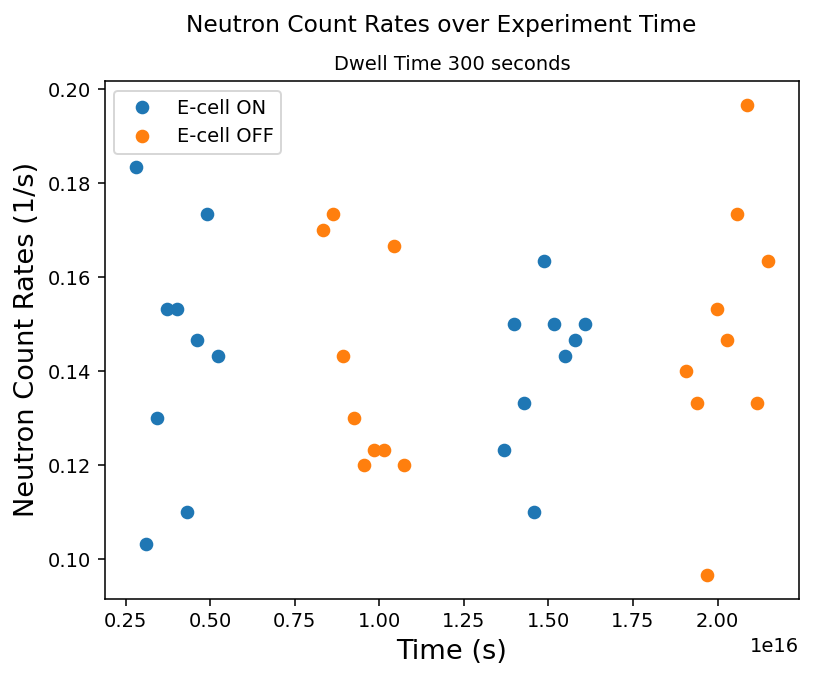

In [35]:
# Plot rates over time, labelled by condition/background

fig, ax = plot_histogram(
    [ecell_on_bins, ecell_off_bins],
    [ecell_on_cps, ecell_off_cps],
    labels=["E-cell ON", "E-cell OFF"]
)

plt.suptitle("Neutron Count Rates over Experiment Time")
plt.title(f"Dwell Time {dwell_time} seconds", fontsize="medium")
ax.set_ylabel("Neutron Count Rates (1/s)", fontsize=14)
ax.set_xlabel("Time (s)", fontsize=14)

### Trial CPS Histograms

In [36]:
# Function definition
def get_mean_rate_from_histogram(
    counts: np.ndarray, 
    bin_bounds: np.ndarray
) -> float:
    bin_widths = np.diff(bin_bounds)
    bin_low_bounds = bin_bounds[:-1]
    bin_midpoint_rates = bin_widths / 2 + bin_low_bounds
    
    weighted_rates = counts*bin_midpoint_rates
    total_weighted_rate = np.sum(weighted_rates, axis=None)
    total_count = np.sum(counts, axis=None)
    mean_rate = total_weighted_rate / total_count
    return mean_rate

Trial 1:
Weighted mean condition rate: 0.1520, SD: 0.0639
Weighted mean background rate: 0.1424, SD: 0.0531
Trial 2:
Weighted mean condition rate: 0.1386, SD: 0.0347
Weighted mean background rate: 0.1488, SD: 0.0532


Text(0.5, 0.98, 'Neutron Count Rate Distributions\nDwell Time 60 seconds, 20 Rate Bins')

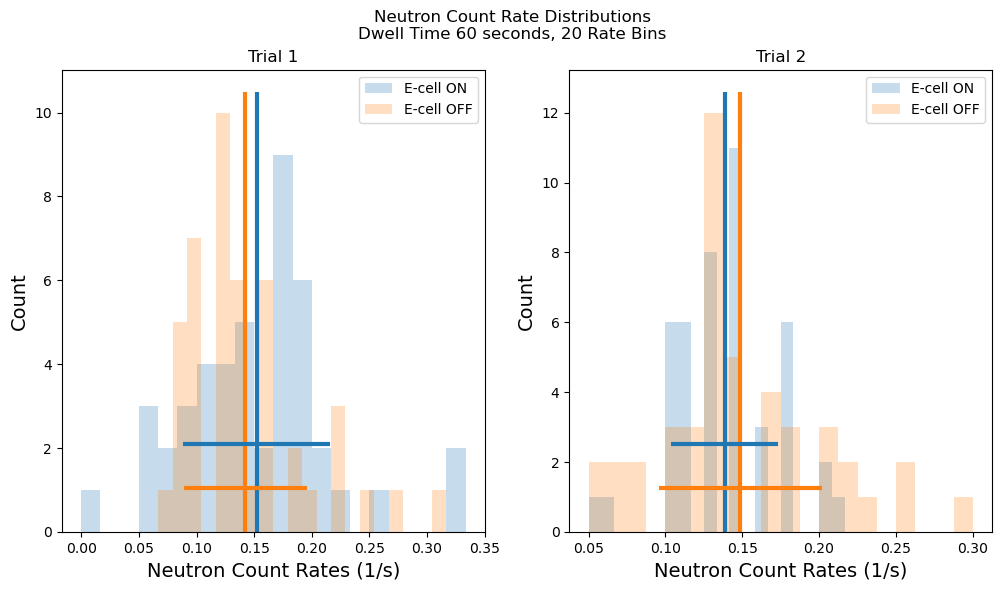

In [37]:
# Plot CPS histogram for each trial

dwell_time = 60*1
ideal_columns = 4
cps_n_bins = 20

exp_count = len(trials)
columns = min(exp_count, ideal_columns)
rows = -(-exp_count // ideal_columns)

fig, axs = plt.subplots(rows, columns, squeeze=False, figsize=(12, 6))
axs_flattened = [ax for row in axs for ax in row]

for i, (ax, trial) in enumerate(list(zip(axs_flattened, trials))):
    cond_counts, cond_bin_bounds = trial.condition_rate_histogram(
        dwell_time, cps_n_bins)
    bg_counts, bg_bin_bounds = trial.background_rate_histogram(
        dwell_time, cps_n_bins)
    
    cond_rates, _ = trial.condition_rate_over_time(dwell_time)
    bg_rates, _ = trial.background_rate_over_time(dwell_time)
    sigma_cond_rate = np.std(cond_rates)
    sigma_bg_rate = np.std(bg_rates)
    
    mean_cond_rate = get_mean_rate_from_histogram(
        cond_counts, cond_bin_bounds)
    mean_bg_rate = get_mean_rate_from_histogram(
        bg_counts, bg_bin_bounds)
    
    print(f"Trial {i+1}:")
    print(f"Weighted mean condition rate: {mean_cond_rate:.4f}, SD: {sigma_cond_rate:.4f}")
    print(f"Weighted mean background rate: {mean_bg_rate:.4f}, SD: {sigma_bg_rate:.4f}")

    stairs_format = dict(lw=2, alpha=0.25, fill=True)
    ax.stairs(cond_counts, cond_bin_bounds, 
              label="E-cell ON", 
              **stairs_format)
    ax.stairs(bg_counts, bg_bin_bounds, 
              label="E-cell OFF", 
              **stairs_format)
    
    ylim_lo, ylim_hi = ax.get_ylim()
    best_x_lim = ax.get_xlim()
    bg_sigma_y = 0.1 * (ylim_hi - ylim_lo) + ylim_lo
    cond_sigma_y = 0.2 * (ylim_hi - ylim_lo) + ylim_lo
    
    lines_format = dict(colors=["C0", "C1"], 
                        linestyles='solid', 
                        linewidth=3)
    ax.vlines([mean_cond_rate, mean_bg_rate], 
              ylim_lo, ylim_hi, 
              **lines_format)
    ax.hlines([cond_sigma_y, bg_sigma_y],
              [mean_cond_rate - sigma_cond_rate, 
               mean_bg_rate - sigma_bg_rate],
              [mean_cond_rate + sigma_cond_rate, 
               mean_bg_rate + sigma_bg_rate],
              **lines_format)
#     ax.set_xlim(*best_x_lim)  # Fix x limits when sigma is too big
    
    ax.set_xlabel("Neutron Count Rates (1/s)", fontsize=14)
    ax.set_ylabel("Count", fontsize=14)
    ax.set_title(f"Trial {i+1}")
    ax.legend()
    
plt.suptitle(f"Neutron Count Rate Distributions\nDwell Time {dwell_time} seconds, {cps_n_bins} Rate Bins")

In [38]:
end_dt = datetime.now()
elapsed = end_dt - start_dt
print(f"Total run time: {elapsed.total_seconds():.3f} s")

Total run time: 17.805 s
